In [ ]:
### STEP 1: IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
from PIL import Image

# Set working directory (optional)
os.chdir("W:/Project/MPI_Registration/Proj_Spatial_Registration")  # <- adjust according to your project

# Define input/output directories
r_tab_dir = 'results/r_output/'       # R-generated tables and CSV files
r_img_dir = 'results/plots/'          # R-generated images
out_dir = 'results/py_output/'        # Python output
ref_dir = 'data/reference/'           # Reference image folder

# Define Visium sample slice names
paths = ["ABCA7-5-a1-7", "BIN1-5-a3-8"]  # <- update this list for your slides

# Load Visium images and query landmarks
query_images = [cv2.imread(os.path.join(r_img_dir, f"{path}_hires_image.png")) for path in paths]
query_landmarks = pd.read_csv(os.path.join(r_tab_dir, "Query_Reference_Landmarks_for_Visium_Data.csv"), index_col=[0, 1])

# Load reference image and reference landmarks
reference_image = cv2.imread(os.path.join(ref_dir, "40x_Wt-317-a4_6mo_(1)_Visium_2A_nl.png"))
reference_image = cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB)
reference_landmarks = pd.read_csv(os.path.join(r_tab_dir, "Reference_Landmarks_for_Spatial_Registration.csv"), index_col=[0, 1])

# Store sample names for later use
samples = paths


In [2]:
# Functions to perform alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    """
    Calculate the homography matrix to map the reference image into query image space.
    This uses matched landmarks (X and Y rows) for each image.
    """

    # Keep only coordinate columns (V1 to V16)
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # Ensure the reference has no missing values
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1]), "Reference has missing landmark coordinates."

    # Keep only landmarks present in both query and reference
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    # Convert from DataFrame to NumPy array and transpose for OpenCV
    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    # Compute homography matrix (no RANSAC)
    return cv2.findHomography(query_coords, reference_coords, method=0)[0], (reference_coords, query_coords)


def transform_points(points, mat):
    """
    Apply a homography matrix to transform a set of 2D points.
    """
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)


def Reverse(tuples):
    """
    Reverse the order of dimensions in a tuple (used for image shape to width-height).
    """
    return tuples[::-1]


In [3]:
query_landmarks.sample_ID.unique().tolist()

['results/plots/ABCA7-5-a1-7', 'results/plots/BIN1-5-a3-8']

In [4]:
reference_landmarks.head(2)

sample_ID           V1           V2           V3  \
Sample Coordinates                                                     
0      X            reference  3125.267433  3414.597751  5360.344139   
       Y            reference   170.614067    76.581714   438.244611   

                             V4           V5           V6           V7  \
Sample Coordinates                                                       
0      X            6083.669934  5678.607489  4448.953638  3479.697073   
       Y            1400.267918  2311.658419  2362.291225  2600.988737   

                             V8           V9          V10          V11  \
Sample Coordinates                                                       
0      X            2524.907024  1338.652720   297.063576  1042.089144   
       Y            2456.323578  2427.390547  1602.799140   611.842802   

                            V12          V13          V14          V15  \
Sample Coordinates                                                       
0      X            2908.269695  3139.733949  4203.022868  3183.133497   
       Y             141.681035   684.175381   727.574929   915.639635   

                            V16  
Sample Coordinates               
0      X            2033.045483  
       Y             872.240088

In [5]:
# STEP 2 - Image alignment and transformations

# Although the reference image is manually annotated, we technically treat the query images
# as the spatial reference space, meaning we project the reference image onto each Visium image.

# Compute homography matrices for each Visium sample
temp = [
    calculate_homography_matrix(
        reference_coords=query_landmarks.iloc[(2 * i):(2 * i + 2), :],
        query_coords=reference_landmarks
    )
    for i in range(len(query_images))
]

# Unpack transformation matrices and landmark coordinate sets
mats, coord_sets = zip(*temp)

# Apply transformations: warp reference image and landmarks into each Visium sample space
images_transformed = [
    cv2.warpPerspective(reference_image, mat, Reverse(img.shape)[1:3])
    for img, mat in zip(query_images, mats)
]
landmarks_transformed = [
    transform_points(landmark, mat)
    for (_, landmark), mat in zip(coord_sets, mats)
]

# Number of samples and number of landmarks
nrow = len(query_images)
n_features = 16


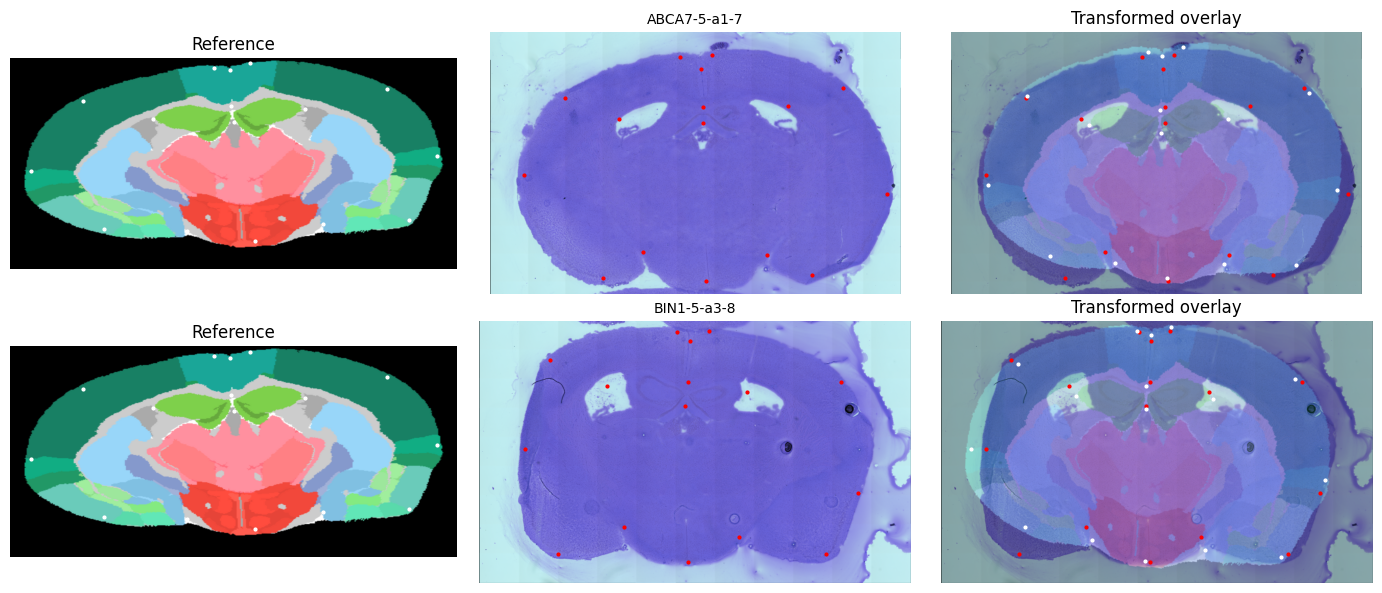

In [6]:
# STEP 3 - Display results of transformation and registration

import re
plt.figure(figsize=(14, nrow * 3))

for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed) in enumerate(
    zip(samples, coord_sets, landmarks_transformed, query_images, images_transformed)
):
    # Panel 1: Reference image with landmarks
    plt.subplot(nrow, 3, 3 * i + 1)
    plt.title('Reference')
    plt.imshow(reference_image)
    plt.plot(
        reference_landmarks.iloc[0, :].filter(regex='V').values,
        reference_landmarks.iloc[1, :].filter(regex='V').values,
        'o', c="white", markersize=2
    )
    plt.axis('off')

    # Panel 2: Original Visium image (query) with its landmarks
    plt.subplot(nrow, 3, 3 * i + 2)
    plt.title(re.sub("_hires.png", "", sample), fontsize=10)
    plt.imshow(img)
    plt.plot(
        query_landmarks.iloc[2 * i, :].filter(regex='V').values,
        query_landmarks.iloc[2 * i + 1, :].filter(regex='V').values,
        'o', c="red", markersize=2
    )
    plt.axis('off')

    # Panel 3: Overlay of Visium + Transformed Reference + Landmarks
    plt.subplot(nrow, 3, 3 * i + 3)
    plt.title('Transformed overlay')
    plt.imshow(img)  # base Visium image
    plt.imshow(img_transformed, alpha=0.3)  # overlay transformed reference image
    plt.plot(
        query_landmarks.iloc[2 * i, :].filter(regex='V').values,
        query_landmarks.iloc[2 * i + 1, :].filter(regex='V').values,
        'o', c="red", markersize=2
    )
    plt.plot(
        pd.DataFrame(landmark_transformed).iloc[:, 0],
        pd.DataFrame(landmark_transformed).iloc[:, 1],
        'o', c="white", markersize=2
    )
    plt.axis('off')

# Save full figure
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Spatial_Registration_v4.pdf'), dpi=400)


In [7]:
# STEP 4 - Link each spot to an annotation region

# Save transformed reference images (used as region masks) for each Visium image
for name, image in zip(samples, images_transformed):
    im = Image.fromarray(image)
    im.save(os.path.join(out_dir, f"{name}_hires_region.png"))

# Load color scheme: each region is associated with an RGB color
color_scheme = pd.read_csv(os.path.join(ref_dir, 'Color_Scheme_List.csv'))

# Load spot coordinates (from Seurat or Space Ranger, projected to high-res)
spots_coords = pd.read_csv(os.path.join(r_tab_dir, 'spots_coords_hi_res.csv'))
spots_coords['imagerow'] = spots_coords['imagerow'].round().astype(int)
spots_coords['imagecol'] = spots_coords['imagecol'].round().astype(int)
spots_coords['region'] = "root"

# For each sample image, map the RGB pixel at each spot to a region label
for idx, sample in enumerate(samples):
    im = images_transformed[idx]  # transformed reference image for current sample

    # Filter spot coordinates belonging to the current sample
    sample_spots = spots_coords['slice'] == sample

    for i in spots_coords[sample_spots].index:
        row = spots_coords.loc[i, 'imagerow']
        col = spots_coords.loc[i, 'imagecol']

        # Get RGB value from the transformed image
        color = im[row, col]

        # Skip black (background) pixels
        if np.array_equal(color, np.array([0, 0, 0])):
            continue

        # Match color with region label in color scheme
        match = color_scheme[
            (color_scheme['R'] == color[0]) &
            (color_scheme['G'] == color[1]) &
            (color_scheme['B'] == color[2])
        ]

        if not match.empty:
            spots_coords.loc[i, 'region'] = match['LABEL'].values[0]


In [9]:
# Import spots center coordinates
spots_coords = pd.read_csv(os.path.join(r_tab_dir, 'spots_coords_hi_res.csv'))
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords['region'] = "root"
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")

# For each image, identify the color/region associated at each spot
for idx in range(len(samples)):
    im = images_transformed[idx].copy()
    mask = spots_coords['slice'] == samples[idx]
    
    for i in spots_coords[mask].index:
        row = spots_coords.at[i, 'imagerow']
        col = spots_coords.at[i, 'imagecol']
        height, width = im.shape[:2]

        if 0 <= row < height and 0 <= col < width:
            color = im[row, col]
            if not np.array_equal(color, [0, 0, 0]):
                match = color_scheme['LABEL'][
                    (color_scheme['R'] == color[0]) &
                    (color_scheme['G'] == color[1]) &
                    (color_scheme['B'] == color[2])
                ]
                if not match.empty:
                    spots_coords.at[i, 'region'] = match.values[0]


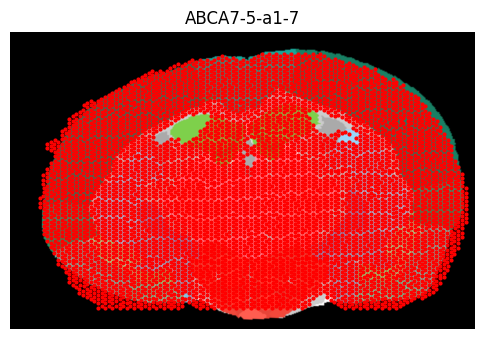

In [10]:
idx = 0  #ABCA7-5-a1-7
plt.figure(figsize=(6,10))
plt.imshow(images_transformed[idx])
plt.plot(spots_coords.imagecol[spots_coords['slice'] == samples[idx]],
         spots_coords.imagerow[spots_coords['slice'] == samples[idx]], 'ro', markersize=2)
plt.title(samples[idx])
plt.axis("off")
plt.show()


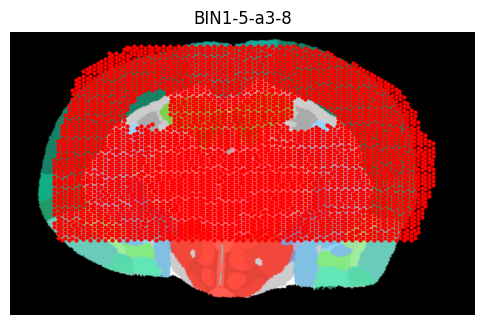

In [11]:
idx = 1  # BIN1-5-a3-8
plt.figure(figsize=(6,10))
plt.imshow(images_transformed[idx])
plt.plot(spots_coords.imagecol[spots_coords['slice'] == samples[idx]],
         spots_coords.imagerow[spots_coords['slice'] == samples[idx]], 'ro', markersize=2)
plt.title(samples[idx])
plt.axis("off")
plt.show()


In [12]:
spots_coords.to_csv(out_dir + "spots_coords_regions.csv") 